In [60]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt


In [61]:
def run_standard_backtest(ticker, start_date, end_date, span_short=9, span_long=51):
    df = yf.download(ticker, start=start_date, end=end_date, progress=False, auto_adjust=True)
    close = df['Close'][ticker] if isinstance(df.columns, pd.MultiIndex) else df['Close']
    data = pd.DataFrame({'Close': close}).dropna()

    # Indicadores e Sinais - sempre comprado ou vendido
    data['EWMA_S'] = data['Close'].ewm(span=span_short, adjust=False).mean()
    data['EWMA_L'] = data['Close'].ewm(span=span_long, adjust=False).mean()
    data['Signal'] = np.where(data['EWMA_S'] > data['EWMA_L'], 1, -1)

    # Retornos Reais
    data['Market_Log_Ret'] = np.log(data['Close']) -  np.log(data['Close'].shift(1))
    #--
    # Retorno logarítmico com alta precisão
#     data['Market_Log_Ret'] = np.log1p(data['Close'].pct_change())
    #--
    data['Strategy_Ret'] = data['Signal'].shift(1) * data['Market_Log_Ret']
    data = data.dropna()


    # Cálculo de Métricas
    anos = len(data) / 252
    cum_market = np.exp(data['Market_Log_Ret'].sum()) - 1
    cum_strategy = np.exp(data['Strategy_Ret'].sum()) - 1
    
    ann_market = (cum_market + 1) ** (1/anos) - 1
    ann_strategy = (cum_strategy + 1) ** (1/anos) - 1
    vol_strategy = data['Strategy_Ret'].std() * np.sqrt(252)
    sharpe = ann_strategy / vol_strategy if vol_strategy > 0 else 0

    print(f"\n--- BACKTEST PADRÃO: {ticker} ---")
    print(f"Retorno Anualizado (Buy & Hold):    {ann_market:.2%}")
    print(f"Retorno Cumulativo da Estratégia:   {cum_strategy:.2%}")
    print(f"Retorno Anualizado da Estratégia:   {ann_strategy:.2%}")
    print(f"Volatilidade Anual Estratégia:      {vol_strategy:.2%}")
    print(f"Índice Sharpe (Estratégia):         {sharpe:.2f}")

    # 7. Visualização (Padrão - Com Tendência)
    plt.figure(figsize=(12, 6))

    # Plot do Benchmark Real (Buy & Hold)
    plt.plot(data.index, np.exp(data['Market_Log_Ret'].cumsum()), 
            label='Buy & Hold (Mercado Real)', color='gray', alpha=0.7, linestyle='--')

    # Plot da Estratégia Real
    plt.plot(data.index, np.exp(data['Strategy_Ret'].cumsum()), 
            label=f'Estratégia EWMA({span_short}/{span_long})', color='blue')

    # Linha de base (Capital Inicial = 1.0)
    plt.axhline(y=1.0, color='black', linewidth=1)

    plt.title(f"Desempenho da Estratégia vs Mercado ({ticker})")
    plt.xlabel("Data")
    plt.ylabel("Multiplicador de Capital (Preços Reais)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    

    return data


--- BACKTEST PADRÃO: ^BVSP ---
Retorno Anualizado (Buy & Hold):    4.84%
Retorno Cumulativo da Estratégia:   67.59%
Retorno Anualizado da Estratégia:   3.83%
Volatilidade Anual Estratégia:      24.25%
Índice Sharpe (Estratégia):         0.16


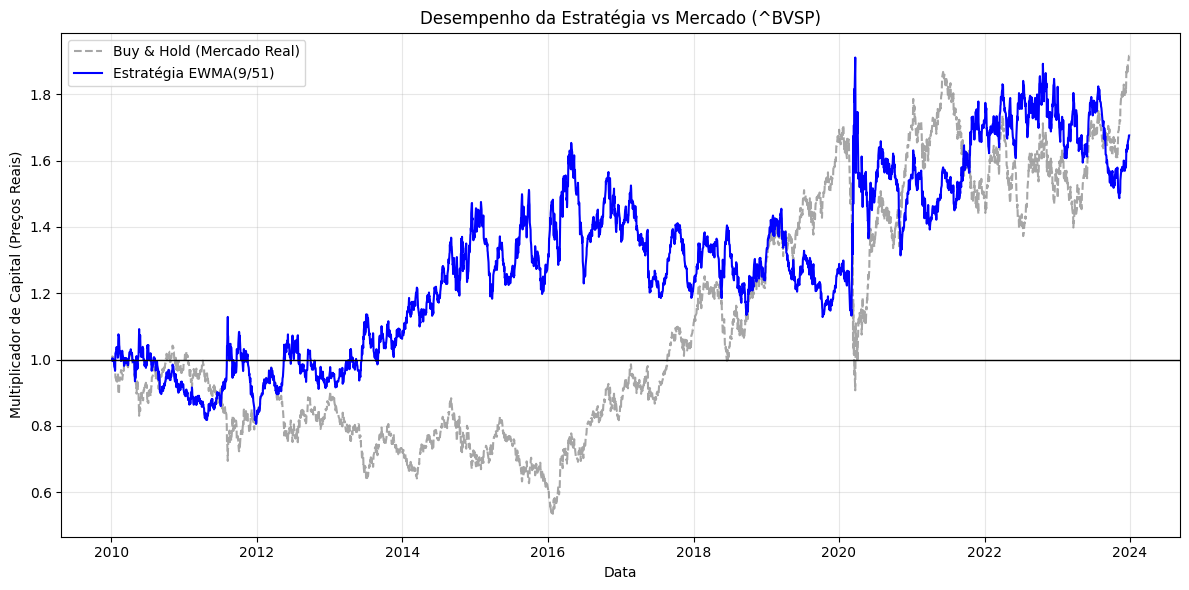

In [62]:
df_resultados = run_standard_backtest(
        ticker="^BVSP", 
        start_date="2010-01-01", 
        end_date="2024-01-01", 
        span_short=9, 
        span_long=51
    )

In [63]:
def run_detrended_ewma_backtest(ticker, start_date, end_date, span_short=9, span_long=51):
    # 1. Coleta de Dados Originais
    df = yf.download(ticker, start=start_date, end=end_date, progress=False, auto_adjust=True)
    close = df['Close'][ticker] if isinstance(df.columns, pd.MultiIndex) else df['Close']
    data = pd.DataFrame({'Close': close}).dropna()
   
    # 2. Geração de Sinais (Usando dados reais/não detrended, conforme o texto)
    data['EWMA_Curta'] = data['Close'].ewm(span=span_short, adjust=False).mean()
    data['EWMA_Longa'] = data['Close'].ewm(span=span_long, adjust=False).mean()
    data['Signal'] = np.where(data['EWMA_Curta'] > data['EWMA_Longa'], 1, -1)

    # 3. Cálculo dos Retornos Logarítmicos e do Benchmark
    data['Log_Return'] = np.log(data['Close']) - np.log(data['Close'].shift(1))
    
    # Média do retorno no período (ADC - Average Daily Change em logs)
    mean_log_return = data['Log_Return'].mean()
    
    # 4. Processo de Detrending
    # Subtrai a média do período de cada retorno diário individual
    data['Detrended_Return'] = data['Log_Return'] - mean_log_return

    # 5. Aplicação da Regra na Série Detrended
    # O shift(1) garante que operamos no retorno do dia 't' com a informação do fechamento de 't-1'
    data['Strategy_Detrended_Return'] = data['Signal'].shift(1) * data['Detrended_Return']

    # 6. Avaliação de Desempenho
    data = data.dropna()
    
    # Retorno cumulativo para plotagem (convertendo de log para escala multiplicadora normal)
    # Note que o Benchmark (Mercado Detrended) será 1.0 no final (ou seja, lucro/prejuízo 0%)
    data['Market_Detrended_Cumulative'] = np.exp(data['Detrended_Return'].cumsum())
    data['Strategy_Detrended_Cumulative'] = np.exp(data['Strategy_Detrended_Return'].cumsum())

    # Métricas finais
    anos = len(data) / 252
    retorno_estrat_cumulativo = data['Strategy_Detrended_Cumulative'].iloc[-1] - 1
    retorno_estrat_anual = (data['Strategy_Detrended_Cumulative'].iloc[-1] ** (1 / anos)) - 1
    
    vol_estrat = data['Strategy_Detrended_Return'].std() * np.sqrt(252)
    sharpe_estrat = retorno_estrat_anual / vol_estrat if vol_estrat > 0 else 0

    print("-" * 55)
    print("RESULTADOS DO BACKTEST (SÉRIE COM TENDÊNCIA ZERO)")
    print("-" * 55)
    print(f"Média Diária Removida (ADC em log): {mean_log_return:.6f}")
    print(f"Retorno Cumulativo da Estratégia:   {retorno_estrat_cumulativo:.2%}")
    print(f"Retorno Anualizado da Estratégia:   {retorno_estrat_anual:.2%}")
    print(f"Volatilidade Anual Estratégia:      {vol_estrat:.2%}")
    print(f"Índice Sharpe (Estratégia):         {sharpe_estrat:.2f}")
    print("-" * 55)
    
    # 7. Visualização
    plt.figure(figsize=(12, 6))
    plt.plot(data.index, data['Market_Detrended_Cumulative'], 
             label='Benchmark Neutro (Mercado sem Tendência)', color='gray', alpha=0.7, linestyle='--')
    plt.plot(data.index, data['Strategy_Detrended_Cumulative'], 
             label=f'Poder Preditivo Puro: EWMA({span_short}/{span_long})', color='darkred')
    
    # Linha do zero (Multiplicador 1.0)
    plt.axhline(y=1.0, color='black', linewidth=1)
    
    plt.title(f"Avaliação de Poder Preditivo via Detrending ({ticker})")
    plt.xlabel("Data")
    plt.ylabel("Multiplicador de Capital (Série Detrended)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return data


-------------------------------------------------------
RESULTADOS DO BACKTEST (SÉRIE COM TENDÊNCIA ZERO)
-------------------------------------------------------
Média Diária Removida (ADC em log): 0.000188
Retorno Cumulativo da Estratégia:   57.97%
Retorno Anualizado da Estratégia:   3.38%
Volatilidade Anual Estratégia:      24.25%
Índice Sharpe (Estratégia):         0.14
-------------------------------------------------------


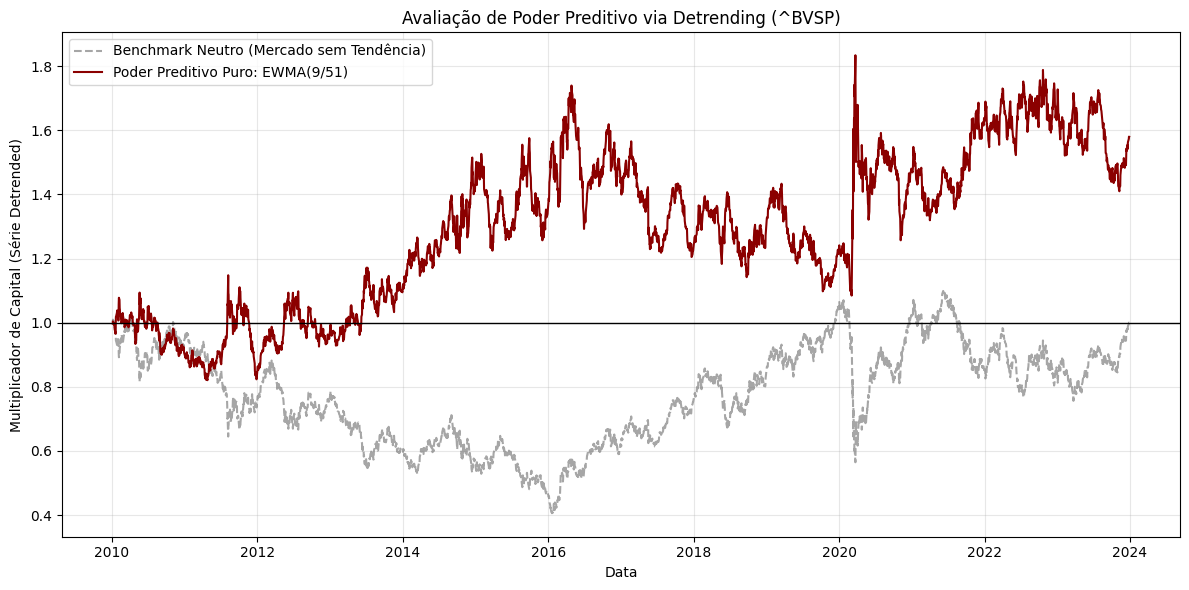

In [64]:
df_resultados = run_detrended_ewma_backtest(
        ticker="^BVSP", 
        start_date="2010-01-01", 
        end_date="2024-01-01", 
        span_short=9, 
        span_long=51
    )